## INTRODUCTION

## PROBLEM STATEMENT

## OBJECTIVE

## Import Libraries

In [13]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D,Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


## DATASET DESCRIPTION

## Extract Dataset

In [4]:
extract_path = r"C:\Users\Lakshmitulasi\Downloads\PRCP-1001-RiceLeaf\data"

## DATASET OVERVIEW

## Data Preprocessing + Data Augmentation

In [5]:
img_size = 224
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    extract_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    extract_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


## Build CNN Model

In [6]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(3, activation='softmax'))

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile Model

In [7]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [8]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3646 - loss: 1.9102 - val_accuracy: 0.3478 - val_loss: 1.1043
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3438 - loss: 1.1195 - val_accuracy: 0.3478 - val_loss: 1.0811
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3333 - loss: 1.0934 - val_accuracy: 0.3478 - val_loss: 1.0491
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3958 - loss: 1.0766 - val_accuracy: 0.4783 - val_loss: 1.0089
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4792 - loss: 1.0306 - val_accuracy: 0.5217 - val_loss: 0.9588
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4167 - loss: 1.0389 - val_accuracy: 0.5652 - val_loss: 0.9309
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5417 - loss: 1.0031 - val_accuracy: 0.5652 - val_loss: 1.0198
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5000 - loss: 0.9543 - val_accuracy: 0.4348 - val_loss: 0.8988
Epoch 9/

## Plot Accuracy

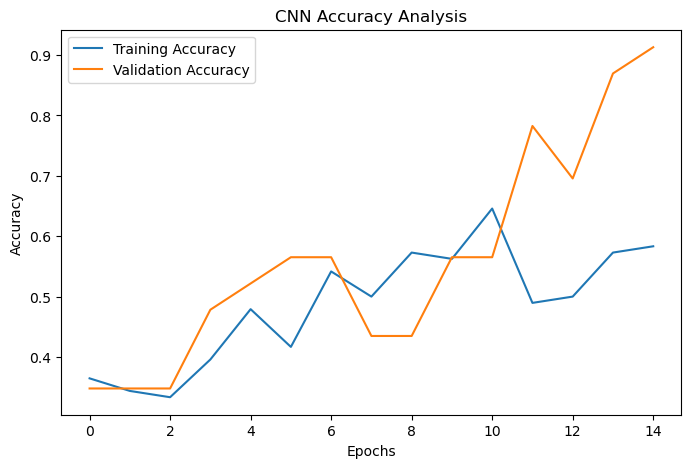

In [10]:
plt.figure(figsize=(8,5))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Analysis')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## ANALYSIS

## Build MobileNet Model (TransferLearning)

In [14]:
inputs = Input(shape=(224,224,3))


base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)


base_model.trainable = False

In [26]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(3, activation='softmax')(x)

# Final model
mobilenet_model = Model(inputs=base_model.input, outputs=outputs)

## Define Early Stopping

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Compile Model

In [28]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train With EarlyStopping

In [29]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4167 - loss: 1.3794 - val_accuracy: 0.7391 - val_loss: 0.8146
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6250 - loss: 1.0306 - val_accuracy: 0.8261 - val_loss: 0.5474
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6771 - loss: 0.7819 - val_accuracy: 0.8261 - val_loss: 0.5103
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8333 - loss: 0.5150 - val_accuracy: 0.8696 - val_loss: 0.3834
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8958 - loss: 0.3847 - val_accuracy: 0.8261 - val_loss: 0.4191
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8750 - loss: 0.3871 - val_accuracy: 0.8696 - val_loss: 0.3404
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9062 - loss: 0.3177 - val_accuracy: 0.8696 - val_loss: 0.4274
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8646 - loss: 0.3586 - val_accuracy: 0.8261 - val_loss: 0.3791
Epoch 9/1

## Plot Accuracy

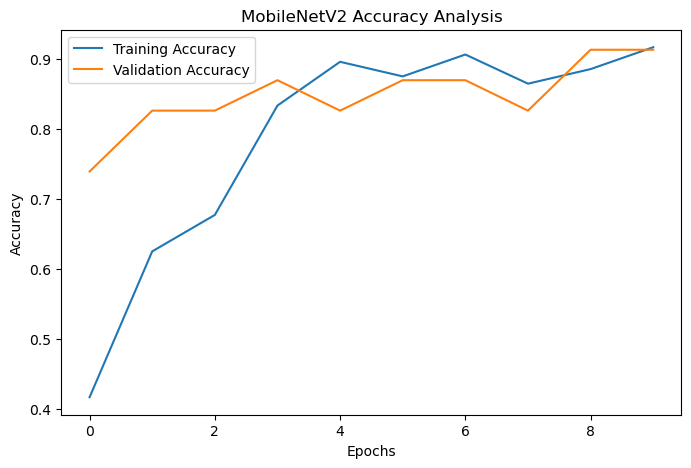

In [30]:
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Accuracy Analysis')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## ANALYSIS

## Compare Final Accuracy

In [32]:
cnn_final_acc = cnn_history.history['val_accuracy'][-1]
tl_final_acc = history_mobilenet.history['val_accuracy'][-1]

print("Final CNN Validation Accuracy:", cnn_final_acc)
print("Final MobileNetV2 Validation Accuracy:", tl_final_acc)

Final CNN Validation Accuracy: 0.9130434989929199
Final MobileNetV2 Validation Accuracy: 0.9130434989929199


## Save CNN Model

In [33]:
from tensorflow.keras.models import load_model
cnn_model.save("rice_leaf_cnn_model.keras")
print("CNN model saved successfully!")

CNN model saved successfully!


## Save TransferLearning Model

In [34]:
from tensorflow.keras.models import load_model
mobilenet_model.save("rice_leaf_mobilenet_model.keras")
print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


## RESULTS

## CHALLENGES FACED

## CONCLUSION